In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Fraud Detection

In [2]:
data = pd.read_csv('creditcard_for_fraud_detection.csv')

In [3]:
data.drop('Class', inplace=True, axis=1)

In [4]:
data = data.dropna()

In [5]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99


In [6]:
from sklearn.ensemble import IsolationForest

Anomalies detected: 570


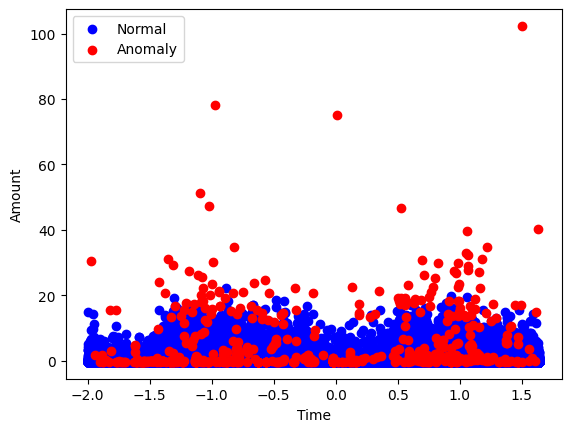

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data[['Time', 'Amount']] = scaler.fit_transform(data[['Time', 'Amount']])

iso_forest = IsolationForest(contamination=0.002)
data['Anomaly'] = iso_forest.fit_predict(data)

# -1 indicates anomaly and 1 indicates normal
data['Anomaly'] = data['Anomaly'].map({1: 0, -1: 1})

# Count the anomalies detected
anomalies_detected = data['Anomaly'].sum()

print(f"Anomalies detected: {anomalies_detected}")

plt.scatter(data[data['Anomaly'] == 0]['Time'], data[data['Anomaly'] == 0]['Amount'], c='blue', label='Normal')
plt.scatter(data[data['Anomaly'] == 1]['Time'], data[data['Anomaly'] == 1]['Amount'], c='red', label='Anomaly')
plt.xlabel('Time')
plt.ylabel('Amount')
plt.legend()
plt.show()


# 2) Customer Profiling

In [8]:
df = pd.read_csv('Credit Card Customer Data.csv')

In [9]:
df.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


## a)

In [10]:
df = df.dropna()

In [11]:
df = ((df - df.min()) / (df.max() - df.min())) * 9 + 1

In [12]:
df.describe()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
count,660.000000,660.000000,660.000000,660.000000,660.000000,660.000000,660.000000
mean,5.500000,5.458082,2.442478,4.706061,5.325455,2.563636,4.225000
std,2.603989,2.603919,1.718931,2.167835,2.937263,1.761434,2.578785
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,3.250000,3.292242,1.319797,3.000000,2.800000,1.600000,1.900000
50%,5.500000,5.329354,1.685279,5.000000,4.600000,2.200000,3.700000
75%,7.750000,7.699604,3.055838,6.000000,8.200000,3.400000,5.500000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


In [13]:
def random_centroids(data, k):
    centroids = []
    for i in range(k):
        centroid = data.apply(lambda x: float(x.sample().iloc[0])) #return a random column from the data
        centroids.append(centroid)
    return pd.concat(centroids, axis=1)

def get_labels(data, centroids):
    distances = centroids.apply(lambda x: np.sqrt(((data - x) ** 2).sum(axis=1)))
    return distances.idxmin(axis=1) #return which cluster index has the min distance from the centroid

def new_centroids(data, labels, k):
    #taking geometric mean of each cluster
    centroids = data.groupby(labels).apply(lambda x: np.exp(np.log(x).mean())).T
    return centroids

from sklearn.decomposition import PCA
from IPython.display import clear_output

def plot_clusters(data, labels, centroids, iteration):
    pca = PCA(n_components=2)
    data_2d = pca.fit_transform(data)
    centroids_2d = pca.transform(centroids.T)
    clear_output(wait=True)
    plt.title(f'Iteration {iteration}')
    plt.scatter(x=data_2d[:,0], y=data_2d[:,1], c=labels)
    plt.scatter(x=centroids_2d[:,0], y=centroids_2d[:,1])
    plt.show()

def k_means_clustering(data, k, max_iter=100, plot=False):
    centroids = random_centroids(data, k)
    old_centroids = pd.DataFrame()
    iteration = 1

    while iteration < max_iter and not centroids.equals(old_centroids):
        old_centroids = centroids
        labels = get_labels(data, centroids)
        centroids = new_centroids(data, labels, k)
        if plot:
            plot_clusters(data, labels, centroids, iteration)
        iteration += 1

    return labels, centroids

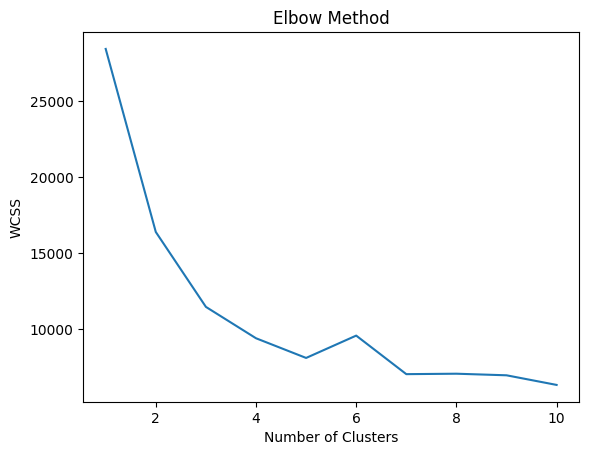

In [14]:
def calculate_wcss(data, max_k):
    wcss = []
    for k in range(1, max_k + 1):
        labels, centroids = k_means_clustering(data, k)
        wcss.append(np.sum((data.to_numpy() - centroids[labels].to_numpy().T) ** 2))
    return wcss

wcss = calculate_wcss(df, 10)
plt.plot(range(1, 11), wcss)
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

#### Using the Elbow method we can take the number of clusters as 7

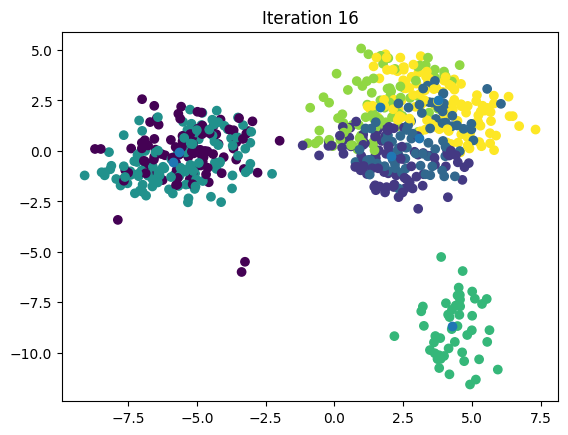

(0      3
 1      0
 2      0
 3      0
 4      0
       ..
 655    4
 656    4
 657    4
 658    4
 659    4
 Length: 660, dtype: int64,
                             0         1         2         3         4  \
 Sl_No                2.312096  6.940022  7.777420  2.426426  9.677210   
 Customer Key         2.645098  7.361339  2.790667  7.242378  4.816888   
 Avg_Credit_Limit     1.450448  2.424300  3.024470  1.423488  7.214653   
 Total_Credit_Cards   2.444429  5.479425  5.219556  1.972030  8.804719   
 Total_visits_bank    2.347560  5.388662  6.538641  2.131195  1.903153   
 Total_visits_online  3.141446  1.441425  1.545659  2.994783  7.318909   
 Total_calls_made     6.755332  2.657007  2.472843  6.879652  1.759863   
 
                             5         6  
 Sl_No                5.126767  6.666894  
 Customer Key         2.807429  6.936845  
 Avg_Credit_Limit     1.412098  2.216097  
 Total_Credit_Cards   5.498816  5.386006  
 Total_visits_bank    6.923147  9.239993  
 Total_vis

In [15]:
k_means_clustering(df, 7, 100, True)

## b)

In [16]:
df.corr()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
Sl_No,1.000000,0.052886,0.677962,0.739329,0.406438,0.033916,-0.684125
Customer Key,0.052886,1.000000,0.068604,-0.010281,-0.000560,0.022506,0.005968
Avg_Credit_Limit,0.677962,0.068604,1.000000,0.608860,-0.100312,0.551385,-0.414352
Total_Credit_Cards,0.739329,-0.010281,0.608860,1.000000,0.315796,0.167758,-0.651251
Total_visits_bank,0.406438,-0.000560,-0.100312,0.315796,1.000000,-0.551861,-0.506016
Total_visits_online,0.033916,0.022506,0.551385,0.167758,-0.551861,1.000000,0.127299
Total_calls_made,-0.684125,0.005968,-0.414352,-0.651251,-0.506016,0.127299,1.000000


In [17]:
df.drop(columns=['Sl_No','Customer Key', 'Total_visits_bank', 'Total_calls_made'], inplace = True, axis=1 )

In [18]:
X_train, y_train = df.iloc[:529, 1:], df.iloc[:529, 0]
X_test, y_test = df.iloc[529:, 1:], df.iloc[529:, 0]

In [19]:
from numpy.linalg import inv

def get_best_model(X, y):

  (n, p_minus_one) = X.shape
  p = p_minus_one + 1

  new_X = np.ones(shape=(n, p))
  new_X[:, 1:] = X

  return np.dot(np.dot(inv(np.dot(new_X.T, new_X)), new_X.T), y)

def get_predictions(model, X):

  (n, p_minus_one) = X.shape
  p = p_minus_one + 1

  new_X = np.ones(shape=(n, p))
  new_X[:, 1:] = X

  return np.dot(new_X, model)

In [20]:
best_model = get_best_model(X_train, y_train)
y_predict = get_predictions(best_model, X_test)

In [21]:
y_predict

array([2.18903605, 1.91350676, 1.86528738, 1.86528738, 2.23725544,
       2.23725544, 1.88939707, 1.88939707, 2.37502008, 2.37502008,
       1.88939707, 2.39912978, 2.35091039, 2.05127141, 2.05127141,
       2.21314575, 2.39912978, 2.37502008, 1.86528738, 1.91350676,
       2.35091039, 2.35091039, 2.37502008, 2.35091039, 2.37502008,
       2.02716172, 1.91350676, 1.91350676, 2.37502008, 2.21314575,
       2.35091039, 2.21314575, 2.39912978, 2.39912978, 2.05127141,
       2.39912978, 2.23725544, 2.23725544, 2.37502008, 2.21314575,
       2.21314575, 1.88939707, 2.39912978, 2.39912978, 2.35091039,
       1.86528738, 2.0753811 , 2.21314575, 2.0753811 , 2.39912978,
       1.91350676, 1.86528738, 2.21314575, 2.21314575, 2.23725544,
       2.21314575, 2.39912978, 2.39912978, 1.91350676, 1.88939707,
       1.91350676, 2.18903605, 2.05127141, 2.02716172, 1.88939707,
       1.88939707, 2.35091039, 2.18903605, 2.35091039, 2.05127141,
       2.18903605, 2.39912978, 2.0753811 , 2.39912978, 2.18903

In [22]:
y_test

529    2.416244
530    2.598985
531    2.324873
532    3.055838
533    2.507614
         ...   
655    5.385787
656    4.700508
657    7.487310
658    8.720812
659    8.492386
Name: Avg_Credit_Limit, Length: 131, dtype: float64

In [23]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_predict, y_test)

np.float64(2.424712549349118)